## Exercise 1

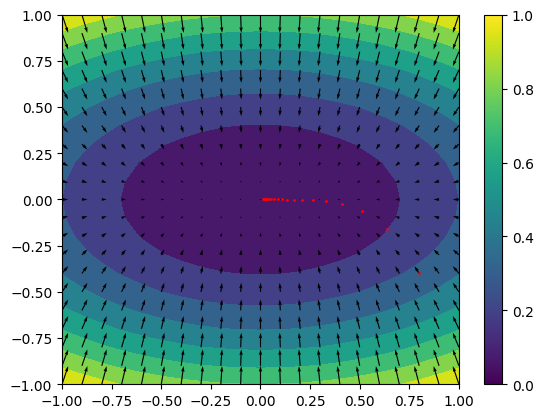

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def f(x, y):
    return x**2 + 3 * y**2


def grad_f(x, y):
    return 2 * x, 6 * y


def gradient_descent(steps, step_size, init_x, init_y, grad_f):
    points_visited = np.zeros((steps, 2))
    points_visited[0, :] = np.array([init_x, init_y])
    for step in range(1, steps):
        prev_point = points_visited[step - 1, :]
        grad_x, grad_y = grad_f(prev_point[0], prev_point[1])
        curr_point = prev_point - step_size * np.array([grad_x, grad_y])
        points_visited[step, :] = curr_point

    return points_visited


steps = 20
step_size = 0.1

points_visited = gradient_descent(steps, step_size, 1.0, -1.0, grad_f)

spacing = 0.1
xy_range = np.arange(-1, 1 + spacing, spacing)
X, Y = np.meshgrid(xy_range, xy_range)
vals = f(X, Y)
U, V = grad_f(X, Y)
plt.contourf(X, Y, vals)
plt.quiver(X, Y, -U, -V)
plt.scatter(points_visited[:, 0], points_visited[:, 1], s=1.0, color="red")
plt.colorbar()
plt.show()


## Exercise 2

![Alternative Text](compute_graph_rosenbrock.png)

The gradient calculated algebraically is 

$$
\begin{align*}
\nabla f &= [-2(1-x) - 400(y-x^2)x, 200(y - x^2)]. \\
\end{align*}
$$

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


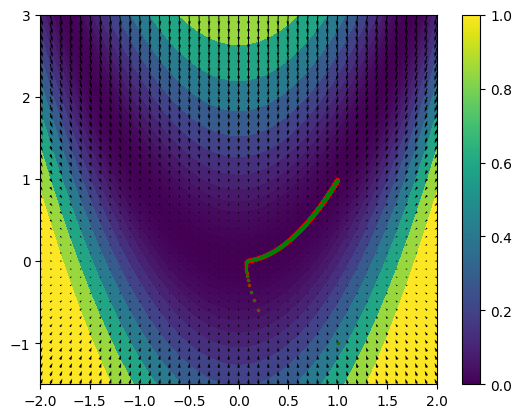

In [2]:
from matplotlib import cm
import jax

jax.config.update("jax_enable_x64", True)


def f(x, y):
    return (1 - x) ** 2 + 100 * (y - x**2) ** 2


def grad_f_numpy(x, y):
    return np.array([-2 * (1 - x) - 400 * (y - x**2) * x, 200 * (y - x**2)])


grad_f_jax = jax.grad(f, argnums=(0, 1))

steps = 10_000
step_size = 1e-3

points_visited_numpy = gradient_descent(steps, step_size, 1.0, -1.0, grad_f_numpy)
points_visited_jax = gradient_descent(steps, step_size, 1.0, -1.0, grad_f_jax)

spacing = 0.1
x_range = np.arange(-2, 2 + spacing, spacing)
y_range = np.arange(-1.5, 3 + spacing, spacing)
X, Y = np.meshgrid(x_range, y_range)
vals = f(X, Y)
U, V = grad_f(X, Y)
plt.contourf(X, Y, vals, levels=np.logspace(0, 3, 20), cmap="viridis", extend="both")
plt.quiver(X, Y, -U, -V)
plt.scatter(
    points_visited_numpy[:, 0],
    points_visited_numpy[:, 1],
    s=2.5,
    color="red",
    label="NumPy Implementation",
)
plt.scatter(
    points_visited_jax[:, 0],
    points_visited_jax[:, 1],
    s=1.0,
    color="green",
    label="JAX Implementation",
)
plt.colorbar()
plt.show()
